# Neural PDE Laboratory · 04
## High dimensions and the annulus

Experiments **7–8** of the laboratory. This notebook is self-contained:
run it in a fresh kernel; no earlier notebook or saved result is required.

[All seven notebooks](Neural_PDE_Laboratory.ipynb) · [Setup and guide](NOTEBOOK_README.md)

Install `experiments/requirements-notebook.txt`, then select **Restart Kernel and
Run All Cells**. The supplied static plots and diagnostics can be read on GitHub.
Interactive explorers are separate, self-contained HTML files in `notebook_outputs/`;
download that folder and open `index.html` in a browser, or regenerate them locally.

Python 3.11+; CPU / float64. Set `RUN_MODE = "thorough"` for longer training runs.

**Notation:** $u$ is the reference state, $u_\theta$ the neural state,
$r_\theta=\mathcal L u_\theta-f$, $\mathcal J$ a continuous residual loss,
$\widehat{\mathcal J}$ its numerical approximation, and $\mathcal E$ an energy.
A hat indicates sampling or quadrature. We check solution error separately from training loss.

In [1]:
# Uncomment only if these packages are missing, then restart the kernel.
# %pip install "numpy>=2.0" scipy matplotlib "torch>=2.2" "plotly>=5.24,<7" ipython

In [2]:
from pathlib import Path
import copy, io, json, math, platform, time
import numpy as np
import scipy
from scipy.linalg import solve_banded
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm
import torch
from torch import nn
import plotly
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, Markdown, Image

RUN_MODE = "quick"               # "quick" or "thorough"
SEED = 7
OUTPUT_DIR = Path.cwd() / "notebook_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
NOTEBOOK_START = time.perf_counter()
metrics = []
FIGURE_NAMES, INTERACTIVE_NAMES = [], []
assert RUN_MODE in {"quick", "thorough"}
torch.set_default_dtype(torch.float64)
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
torch.manual_seed(SEED)
np.random.seed(SEED)
BUDGET = {"adam_1d": 900, "lbfgs_1d": 180, "adam_2d": 1100,
          "lbfgs_2d": 260, "boundary_adam": 900}
if RUN_MODE == "thorough":
    BUDGET = {key: 2 * value for key, value in BUDGET.items()}
versions = {"python": platform.python_version(), "numpy": np.__version__,
            "scipy": scipy.__version__, "matplotlib": matplotlib.__version__,
            "torch": torch.__version__, "plotly": plotly.__version__}
print(json.dumps(versions, indent=2))
print(f"CPU / float64 / seed {SEED} / {RUN_MODE} mode")

{
  "python": "3.13.9",
  "numpy": "2.4.2",
  "scipy": "1.17.0",
  "matplotlib": "3.10.8",
  "torch": "2.10.0",
  "plotly": "6.9.0"
}
CPU / float64 / seed 7 / quick mode


## Reading and saving the plots

Static figures are saved as PNG and PDF and embedded in this notebook. Interactive
plots are saved as offline HTML files: open their links locally to rotate, zoom,
and animate them. GitHub displays the static figures without executing JavaScript.

In [3]:
palette = {"navy": "#10243A", "teal": "#00A6A6", "orange": "#F28C45",
           "pink": "#DC4778", "blue": "#4878D0", "ink": "#183449", "muted": "#63788A"}
plt.rcParams.update({
    "figure.facecolor": "#F7FAFC", "axes.facecolor": "#F7FAFC",
    "axes.edgecolor": "#CAD6DF", "axes.labelcolor": palette["ink"],
    "text.color": palette["ink"], "xtick.color": palette["muted"],
    "ytick.color": palette["muted"], "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 12,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": "#DCE5EB", "grid.alpha": 0.65,
    "lines.linewidth": 2.3, "figure.dpi": 110, "savefig.dpi": 170,
    "legend.frameon": False, "font.family": "DejaVu Sans",
    "axes.prop_cycle": matplotlib.cycler(color=[palette[k] for k in
                                  ["teal", "orange", "pink", "blue", "navy"]]),
})
sea_cmap = LinearSegmentedColormap.from_list("sea", ["#10243A", "#146F88", "#00BBB0", "#F9D879"])
wave_scale = [[0, "#153F7C"], [.25, "#21A9B5"], [.5, "#F7FAFC"],
              [.75, "#FFB16E"], [1, "#C93663"]]

def style_3d(ax, title=None):
    if title:
        ax.set_title(title)
    ax.view_init(elev=28, azim=-128)
    ax.set_box_aspect((1, 1, .65))
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.fill = False
        axis._axinfo["grid"]["color"] = (0.78, 0.84, 0.88, 0.35)
    ax.tick_params(labelsize=8, pad=1)

def save_figure(fig, name):
    if name not in FIGURE_NAMES:
        FIGURE_NAMES.append(name)
    fig.savefig(OUTPUT_DIR / f"{name}.png", bbox_inches="tight")
    fig.savefig(OUTPUT_DIR / f"{name}.pdf", bbox_inches="tight")
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", dpi=130, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))
    plt.close(fig)

def show_interactive(fig, name):
    if name not in INTERACTIVE_NAMES:
        INTERACTIVE_NAMES.append(name)
    fig.update_layout(template="plotly_dark", paper_bgcolor="#10243A",
                      plot_bgcolor="#10243A", font=dict(family="Arial", size=13),
                      margin=dict(l=40, r=55, t=130, b=75), height=680)
    fig.update_layout(title=dict(x=.035, y=.97, xanchor="left", font=dict(size=19)))
    for menu in fig.layout.updatemenus:
        menu.update(y=1.04, yanchor="bottom", x=0, xanchor="left",
                    bgcolor="#E5EFF5", bordercolor="#9FB8CA",
                    font=dict(color="#10243A", size=12))
    fig.update_scenes(bgcolor="#10243A",
        xaxis=dict(backgroundcolor="#10243A", gridcolor="#31506C"),
        yaxis=dict(backgroundcolor="#10243A", gridcolor="#31506C"),
        zaxis=dict(backgroundcolor="#10243A", gridcolor="#31506C"))
    config = {"displaylogo": False, "responsive": True}
    fig.write_html(OUTPUT_DIR / f"{name}.html", include_plotlyjs=True,
                   full_html=True, config=config, auto_play=False)
    # Keep notebook previews small: JavaScript and animation data live in HTML.
    relative = (OUTPUT_DIR / f"{name}.html").relative_to(Path.cwd()).as_posix()
    display(Markdown(f"[Open interactive explorer]({relative}) — "
                     "open locally in a browser; GitHub previews show the static plots."))

def grad_scalar(u, x):
    return torch.autograd.grad(u.sum(), x, create_graph=True)[0]

def mlp(input_dim, width=32, depth=2):
    layers = [nn.Linear(input_dim, width), nn.Tanh()]
    for _ in range(depth - 1):
        layers.extend([nn.Linear(width, width), nn.Tanh()])
    return nn.Sequential(*layers, nn.Linear(width, 1))

def train_model(model, objective, adam_steps, lbfgs_steps=0, diagnostic=None):
    """Log each objective evaluation, including repeated L-BFGS closure calls."""
    start = time.perf_counter()
    history = {"evaluation": [], "loss": [], "error_eval": [], "error": []}
    evaluations = 0
    opt = torch.optim.Adam(model.parameters(), lr=2e-3)
    def evaluate():
        nonlocal evaluations
        value = objective()
        evaluations += 1
        history["evaluation"].append(evaluations)
        history["loss"].append(value.detach().item())
        return value
    for step in range(adam_steps):
        opt.zero_grad(set_to_none=True)
        loss = evaluate()
        loss.backward()
        opt.step()
        if diagnostic is not None and (step == 0 or (step + 1) % 100 == 0):
            history["error_eval"].append(evaluations)
            history["error"].append(diagnostic())
    if lbfgs_steps:
        opt = torch.optim.LBFGS(model.parameters(), max_iter=lbfgs_steps,
                 max_eval=2*lbfgs_steps, history_size=40, line_search_fn="strong_wolfe",
                 tolerance_grad=1e-10, tolerance_change=1e-13)
        def closure():
            opt.zero_grad(set_to_none=True)
            value = evaluate()
            value.backward()
            return value
        opt.step(closure)
    if diagnostic is not None:
        history["error_eval"].append(evaluations)
        history["error"].append(diagnostic())
    history["seconds"] = time.perf_counter() - start
    return history

## 7 · High dimensions: sampling and the price of a grid

A tensor grid with 16 nodes in each direction needs $16^d$ points. Neural PDE methods often replace this grid by randomly sampled points. What does that buy us **before** we train a network?

Take the manufactured smooth field
$$u_d(x)=d^{-1/2}\sum_{k=1}^d\sin(\pi x_k),\qquad x\in(0,1)^d.$$
It solves $-\Delta u_d=\pi^2u_d$ with its own prescribed boundary trace. Its Dirichlet energy is exactly
$$\mathcal E_d=\frac12\int_{(0,1)^d}|\nabla u_d|^2\,dx=\frac{\pi^2}{4}.$$
For independent uniform samples, the relative RMS integration error is $1/\sqrt{2dN}$. We estimate this error using 16 independent runs and compare it with the formula. This tests the **integration step** used in neural PDE solvers. The error decreases with $d$ because of this field's additive structure; more general fields need separate analysis. The second panel compares point counts only, with no attempt to match accuracy.

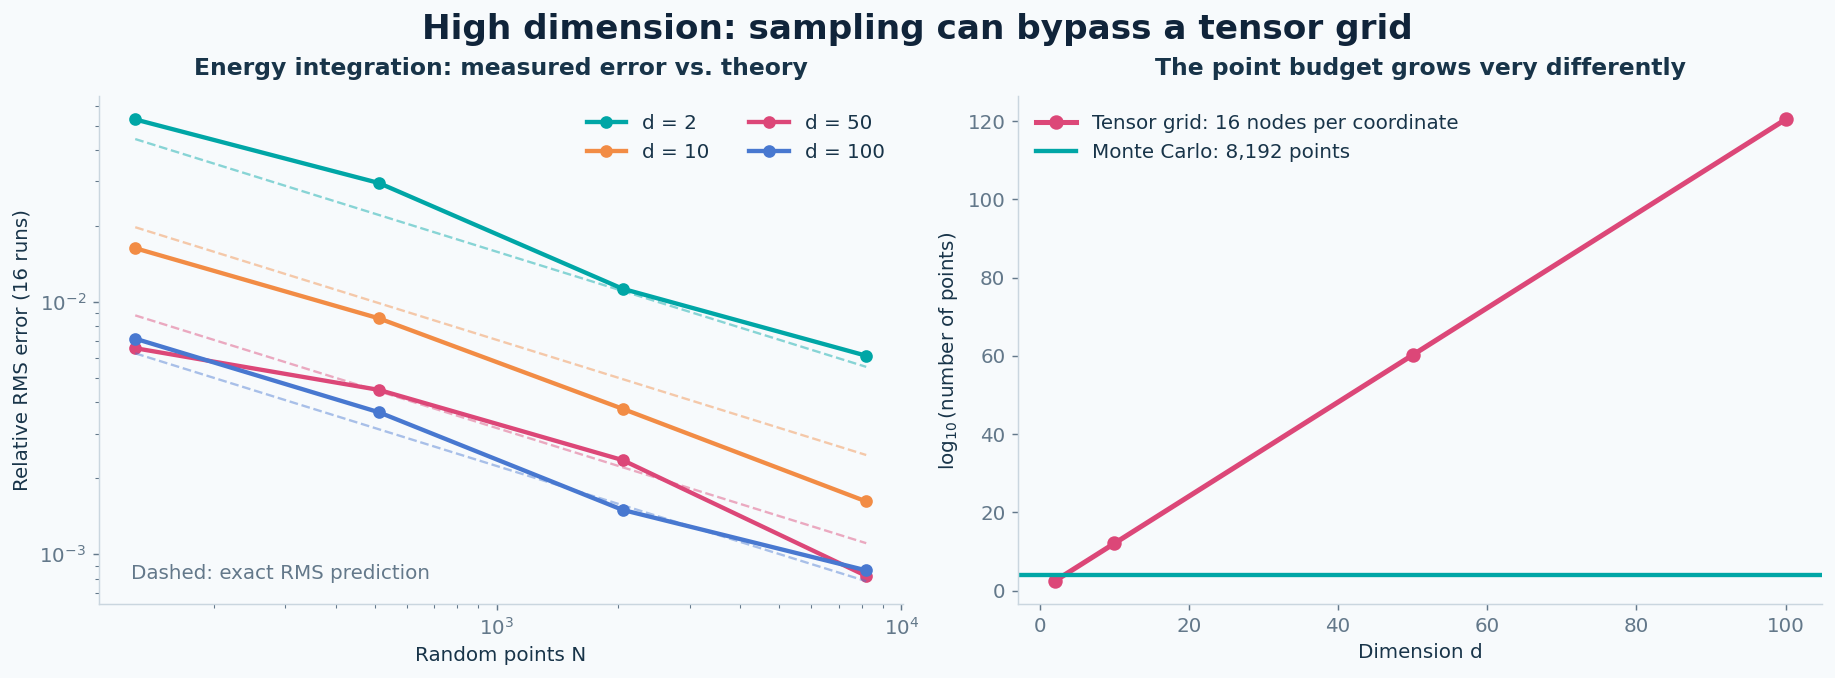

Exact energy = 2.46740110
d =   2 | relative RMS error at N = 8192: 0.612%
d =  10 | relative RMS error at N = 8192: 0.162%
d =  50 | relative RMS error at N = 8192: 0.082%
d = 100 | relative RMS error at N = 8192: 0.086%


In [4]:
# Actual Monte Carlo energy estimates; no training or saved results are used.
hd_rng = np.random.default_rng(1701)
hd_dims = np.array([2, 10, 50, 100])
hd_counts = np.array([128, 512, 2048, 8192])
hd_repeats = 16
hd_energy = np.pi**2 / 4
hd_rmse = np.zeros((len(hd_dims), len(hd_counts)))
for hd_i, hd_d in enumerate(hd_dims):
    hd_errors = []
    for hd_repeat in range(hd_repeats):
        hd_x = hd_rng.random((hd_counts[-1], hd_d))
        hd_density = 0.5 * np.pi**2 * np.mean(np.cos(np.pi * hd_x)**2, axis=1)
        hd_estimates = np.cumsum(hd_density)[hd_counts - 1] / hd_counts
        hd_errors.append(hd_estimates / hd_energy - 1)
    hd_rmse[hd_i] = np.sqrt(np.mean(np.array(hd_errors)**2, axis=0))

hd_colors = [palette['teal'], palette['orange'], palette['pink'], palette['blue']]
hd_fig, hd_ax = plt.subplots(1, 2, figsize=(14, 5.1), constrained_layout=True)
for hd_i, (hd_d, hd_color) in enumerate(zip(hd_dims, hd_colors)):
    hd_ax[0].loglog(hd_counts, hd_rmse[hd_i], 'o-', color=hd_color,
                   lw=2.4, ms=6, label=f'd = {hd_d}')
    hd_ax[0].loglog(hd_counts, 1 / np.sqrt(2 * hd_d * hd_counts), '--',
                   color=hd_color, alpha=0.45, lw=1.3)
hd_ax[0].set(title='Energy integration: measured error vs. theory',
             xlabel='Random points N', ylabel='Relative RMS error (16 runs)')
hd_ax[0].legend(ncol=2, frameon=False)
hd_ax[0].text(0.04, 0.05, 'Dashed: exact RMS prediction',
              transform=hd_ax[0].transAxes, color=palette['muted'])
hd_ax[1].plot(hd_dims, hd_dims * np.log10(16), 'o-', color=palette['pink'],
              lw=2.8, ms=7, label='Tensor grid: 16 nodes per coordinate')
hd_ax[1].axhline(np.log10(hd_counts[-1]), color=palette['teal'], lw=2.4,
                 label='Monte Carlo: 8,192 points')
hd_ax[1].set(title='The point budget grows very differently',
             xlabel='Dimension d', ylabel=r'$\log_{10}$(number of points)')
hd_ax[1].legend(frameon=False, loc='upper left')
hd_fig.suptitle('High dimension: sampling can bypass a tensor grid',
                fontsize=19, fontweight='bold', color=palette['navy'])
save_figure(hd_fig, 'extra_high_dimension')
print(f'Exact energy = {hd_energy:.8f}')
for hd_d, hd_row in zip(hd_dims, hd_rmse):
    print(f'd = {hd_d:3d} | relative RMS error at N = 8192: {hd_row[-1]:.3%}')

## 8 · A neural Poisson solution around a hole

Next, solve a PDE on an annulus, a domain with two circular boundaries. Let $a=0.35$, $b=1$, $s=x^2+y^2$, and
$$\Omega=\{(x,y):a<\sqrt{s}<b\},\qquad
\phi(x,y)=(s-a^2)(b^2-s).$$
We manufacture the exact solution $u=\phi(1+0.35x-0.20y)$ and obtain
$$-\Delta u=f,\quad u|_{\partial\Omega}=0,\qquad
f=16s-4c+(24s-8c)(0.35x-0.20y),\quad c=a^2+b^2.$$
The neural trial is $u_\theta=\phi N_\theta(x,y)$: both circular boundary conditions hold exactly, so training only minimizes an interior strong residual. We sample $r=\sqrt{a^2+(b^2-a^2)U}$ and $\vartheta=2\pi V$ with uniform independent $U,V$. This gives **uniform area sampling**; a uniform radius would overweight the inner part of the annulus.

Here we can construct sample points and a boundary factor directly, so we can train without a volume mesh. More complicated geometries may make either step difficult. A comparison with FEM would also need to measure solution error and total cost.

In [5]:
# A fresh small network and a deterministic area-uniform training set.
import time
torch.manual_seed(1702)
geo_rng = np.random.default_rng(1702)
geo_a, geo_b = 0.35, 1.0
geo_dtype = torch.float64
geo_uv = geo_rng.random((512, 2))
geo_radius = np.sqrt(geo_a**2 + (geo_b**2 - geo_a**2) * geo_uv[:, 0])
geo_angle = 2 * np.pi * geo_uv[:, 1]
geo_xy_np = np.column_stack((geo_radius * np.cos(geo_angle),
                              geo_radius * np.sin(geo_angle)))
geo_xy = torch.tensor(geo_xy_np, dtype=geo_dtype, requires_grad=True)
geo_net = torch.nn.Sequential(
    torch.nn.Linear(2, 24), torch.nn.Tanh(),
    torch.nn.Linear(24, 24), torch.nn.Tanh(),
    torch.nn.Linear(24, 1),
).to(dtype=geo_dtype)

def geo_phi(xy):
    s = (xy**2).sum(dim=1, keepdim=True)
    return (s - geo_a**2) * (geo_b**2 - s)

def geo_trial(xy):
    return geo_phi(xy) * geo_net(xy)

def geo_exact(xy):
    return geo_phi(xy) * (1 + 0.35 * xy[:, :1] - 0.20 * xy[:, 1:2])

def geo_forcing(xy):
    s = (xy**2).sum(dim=1, keepdim=True)
    c = geo_a**2 + geo_b**2
    q = 0.35 * xy[:, :1] - 0.20 * xy[:, 1:2]
    return 16 * s - 4 * c + (24 * s - 8 * c) * q

def geo_laplacian(values, xy, create_graph=True):
    grad = torch.autograd.grad(values.sum(), xy, create_graph=True)[0]
    return sum(torch.autograd.grad(grad[:, j].sum(), xy,
                                   create_graph=create_graph, retain_graph=True)[0][:, j:j+1]
               for j in range(2))

geo_forcing_train = geo_forcing(geo_xy).detach()
# Check the manufactured source independently by automatic differentiation.
geo_source_check = (geo_laplacian(geo_exact(geo_xy), geo_xy) +
                    geo_forcing_train).detach().abs().max().item()
assert geo_source_check < 1e-10
print(f'Manufactured-source check: max |Δu + f| = {geo_source_check:.2e}')

Manufactured-source check: max |Δu + f| = 3.55e-15


In [6]:
# Full-batch L-BFGS. The recorded values include line-search evaluations.
geo_started = time.perf_counter()
geo_history = []
geo_optimizer = torch.optim.LBFGS(geo_net.parameters(), lr=1.0, max_iter=130,
                                 max_eval=180, history_size=30,
                                 tolerance_grad=1e-10, tolerance_change=1e-13,
                                 line_search_fn='strong_wolfe')

def geo_closure():
    geo_optimizer.zero_grad(set_to_none=True)
    if geo_xy.grad is not None:
        geo_xy.grad = None
    residual = -geo_laplacian(geo_trial(geo_xy), geo_xy) - geo_forcing_train
    loss = (residual**2).mean()
    loss.backward()
    geo_history.append(float(loss.detach()))
    return loss

geo_optimizer.step(geo_closure)
geo_seconds = time.perf_counter() - geo_started

# Independent, area-uniform validation points; training samples are not reused.
geo_test_uv = geo_rng.random((4096, 2))
geo_test_r = np.sqrt(geo_a**2 + (geo_b**2 - geo_a**2) * geo_test_uv[:, 0])
geo_test_t = 2 * np.pi * geo_test_uv[:, 1]
geo_test_xy = torch.tensor(np.column_stack((geo_test_r * np.cos(geo_test_t),
                                            geo_test_r * np.sin(geo_test_t))),
                             dtype=geo_dtype, requires_grad=True)
geo_test_pred = geo_trial(geo_test_xy)
geo_test_true = geo_exact(geo_test_xy)
geo_relative_l2 = float((torch.linalg.vector_norm(geo_test_pred - geo_test_true) /
                         torch.linalg.vector_norm(geo_test_true)).detach())
geo_test_res = -geo_laplacian(geo_test_pred, geo_test_xy, create_graph=False) - geo_forcing(geo_test_xy)
geo_test_res_rms = float(torch.sqrt(torch.mean(geo_test_res**2)).detach())
print(f'Training time: {geo_seconds:.1f} s | closure evaluations: {len(geo_history)}')
print(f'Independent relative L² error: {geo_relative_l2:.3%}')
print(f'Independent residual RMS: {geo_test_res_rms:.3e}')
print('Both boundary circles satisfy uθ = 0 by construction.')

Training time: 0.5 s | closure evaluations: 138
Independent relative L² error: 0.030%
Independent residual RMS: 2.443e-03
Both boundary circles satisfy uθ = 0 by construction.


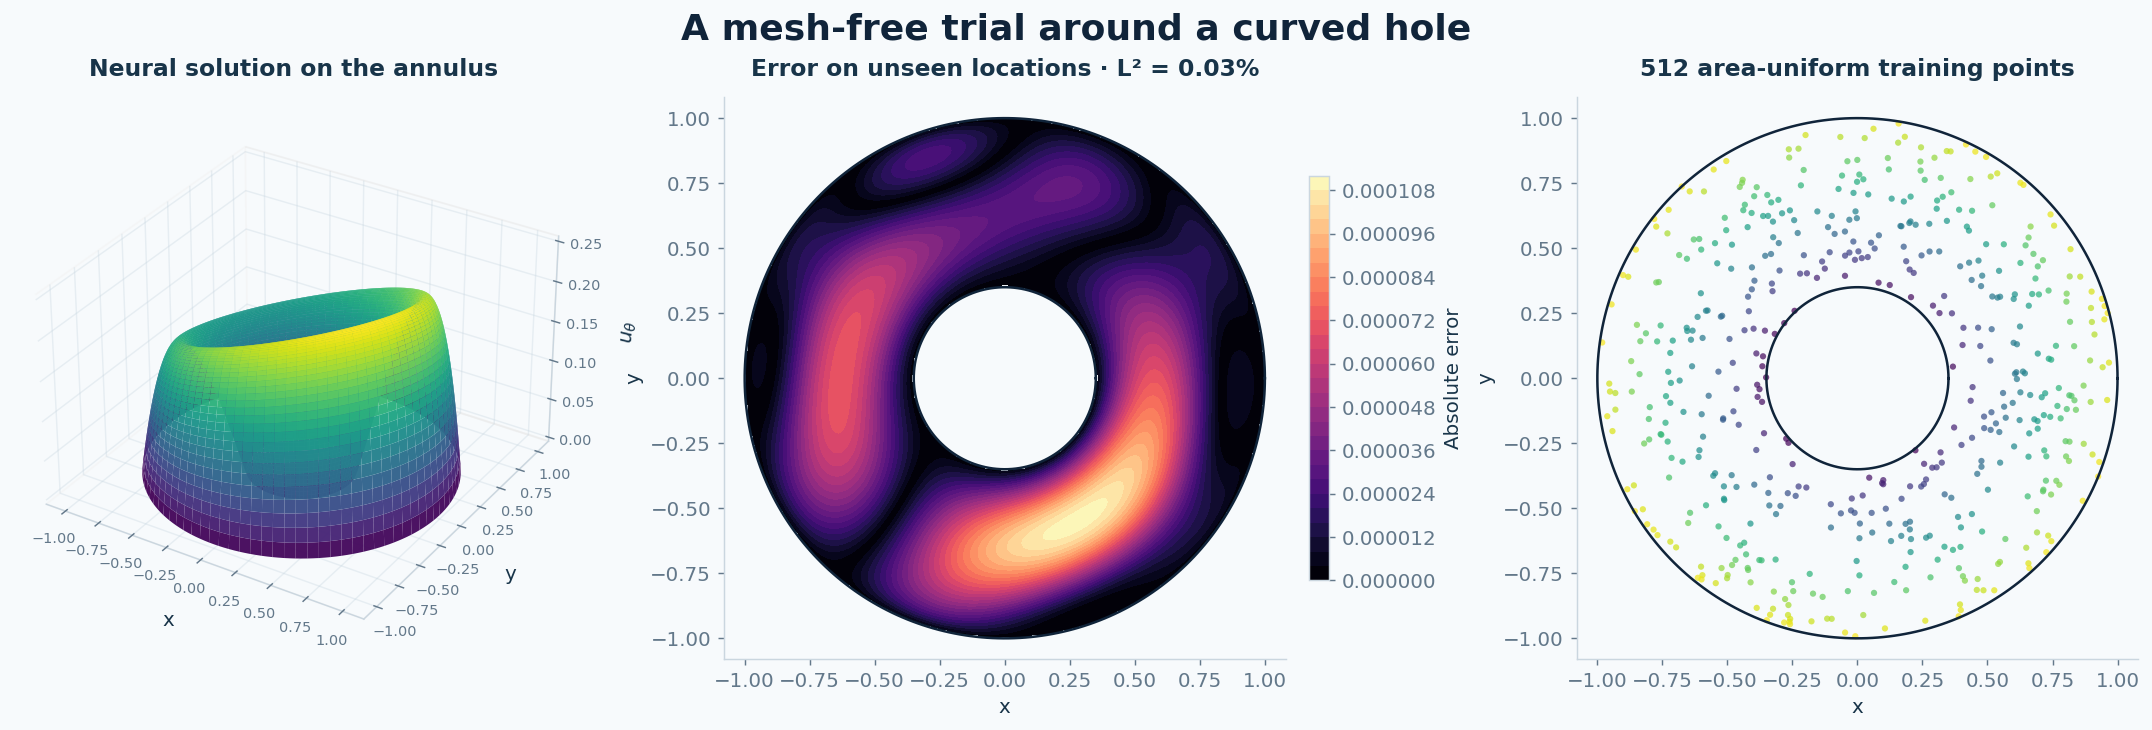

In [7]:
# A curved surface, a spatial error map, and the actual collocation points.
geo_plot_r, geo_plot_t = np.meshgrid(np.linspace(geo_a, geo_b, 80),
                                    np.linspace(0, 2 * np.pi, 181))
geo_plot_x, geo_plot_y = geo_plot_r * np.cos(geo_plot_t), geo_plot_r * np.sin(geo_plot_t)
geo_plot_xy = torch.tensor(np.column_stack((geo_plot_x.ravel(), geo_plot_y.ravel())),
                             dtype=geo_dtype)
with torch.no_grad():
    geo_plot_u = geo_trial(geo_plot_xy).numpy().reshape(geo_plot_x.shape)
    geo_plot_exact = geo_exact(geo_plot_xy).numpy().reshape(geo_plot_x.shape)
geo_grid_line = np.linspace(-1.04, 1.04, 230)
geo_grid_x, geo_grid_y = np.meshgrid(geo_grid_line, geo_grid_line)
geo_grid_s = geo_grid_x**2 + geo_grid_y**2
geo_mask = (geo_grid_s < geo_a**2) | (geo_grid_s > geo_b**2)
geo_grid_xy = torch.tensor(np.column_stack((geo_grid_x.ravel(), geo_grid_y.ravel())),
                             dtype=geo_dtype)
with torch.no_grad():
    geo_grid_err = (geo_trial(geo_grid_xy) - geo_exact(geo_grid_xy)).abs().numpy().reshape(geo_grid_x.shape)
geo_grid_err = np.ma.array(geo_grid_err, mask=geo_mask)
geo_fig = plt.figure(figsize=(17, 5.5), constrained_layout=True)
geo_ax0 = geo_fig.add_subplot(1, 3, 1, projection='3d')
geo_surf = geo_ax0.plot_surface(geo_plot_x, geo_plot_y, geo_plot_u,
                               cmap='viridis', linewidth=0, antialiased=True,
                               rcount=110, ccount=80, alpha=0.97)
style_3d(geo_ax0, 'Neural solution on the annulus')
geo_ax0.set(xlabel='x', ylabel='y', zlabel=r'$u_\theta$')
geo_ax0.view_init(elev=31, azim=-58)
geo_ax1 = geo_fig.add_subplot(1, 3, 2)
geo_im = geo_ax1.contourf(geo_grid_x, geo_grid_y, geo_grid_err,
                         levels=35, cmap='magma')
geo_fig.colorbar(geo_im, ax=geo_ax1, shrink=0.72, pad=0.035, label='Absolute error')
geo_ax1.set(title=f'Error on unseen locations · L² = {geo_relative_l2:.2%}',
             xlabel='x', ylabel='y', aspect='equal')
geo_ax2 = geo_fig.add_subplot(1, 3, 3)
geo_ax2.scatter(geo_xy_np[:, 0], geo_xy_np[:, 1], c=geo_radius,
                cmap='viridis', s=12, alpha=0.72, edgecolors='none')
geo_ax2.set(title='512 area-uniform training points', xlabel='x', ylabel='y', aspect='equal')
geo_circle_t = np.linspace(0, 2 * np.pi, 300)
for geo_ax in (geo_ax1, geo_ax2):
    for geo_r_boundary in (geo_a, geo_b):
        geo_ax.plot(geo_r_boundary * np.cos(geo_circle_t),
                     geo_r_boundary * np.sin(geo_circle_t),
                     color=palette['navy'], lw=1.4)
    geo_ax.set_xlim(-1.08, 1.08)
    geo_ax.set_ylim(-1.08, 1.08)
    geo_ax.grid(False)
geo_fig.suptitle('A mesh-free trial around a curved hole', fontsize=20,
                 fontweight='bold', color=palette['navy'])
save_figure(geo_fig, 'extra_annulus_solution')

In [8]:
# Drag to orbit the annulus; the dropdown changes what the color represents.
geo_interactive_error = np.abs(geo_plot_u - geo_plot_exact)
geo_interactive = go.Figure([
    go.Surface(x=geo_plot_x, y=geo_plot_y, z=geo_plot_u,
               colorscale='Viridis', colorbar=dict(title='Neural u'),
               name='Neural solution', visible=True,
               hovertemplate='x=%{x:.3f}<br>y=%{y:.3f}<br>uθ=%{z:.5f}<extra></extra>'),
    go.Surface(x=geo_plot_x, y=geo_plot_y, z=geo_plot_exact,
               colorscale='Viridis', colorbar=dict(title='Exact u'),
               name='Exact solution', visible=False,
               hovertemplate='x=%{x:.3f}<br>y=%{y:.3f}<br>u=%{z:.5f}<extra></extra>'),
    go.Surface(x=geo_plot_x, y=geo_plot_y, z=geo_plot_u,
               surfacecolor=geo_interactive_error, customdata=geo_interactive_error,
               colorscale='Magma', colorbar=dict(title='|uθ − u|'),
               name='Error painted on the neural surface', visible=False,
               hovertemplate='x=%{x:.3f}<br>y=%{y:.3f}<br>uθ=%{z:.5f}'
                             '<br>|error|=%{customdata:.2e}<extra></extra>'),
])
geo_interactive.update_layout(
    title='Explore the annulus: neural solution', height=640,
    template='plotly_white', margin=dict(l=10, r=10, t=100, b=10),
    scene=dict(xaxis_title='x', yaxis_title='y', zaxis_title='Solution value',
               aspectratio=dict(x=1, y=1, z=0.62),
               camera=dict(eye=dict(x=1.5, y=-1.6, z=1.25))),
    updatemenus=[dict(x=0.01, y=1.10, xanchor='left', yanchor='top', buttons=[
        dict(label='Neural solution', method='update',
             args=[{'visible': [True, False, False]}, {'title': 'Explore the annulus: neural solution'}]),
        dict(label='Exact solution', method='update',
             args=[{'visible': [False, True, False]}, {'title': 'Explore the annulus: exact solution'}]),
        dict(label='Error colors on neural surface', method='update',
             args=[{'visible': [False, False, True]},
                   {'title': 'Height: neural solution · Color: absolute error'}]),
    ])],
)
show_interactive(geo_interactive, 'extra_annulus_interactive')

[Open interactive explorer](notebook_outputs/extra_annulus_interactive.html) — open locally in a browser; GitHub previews show the static plots.

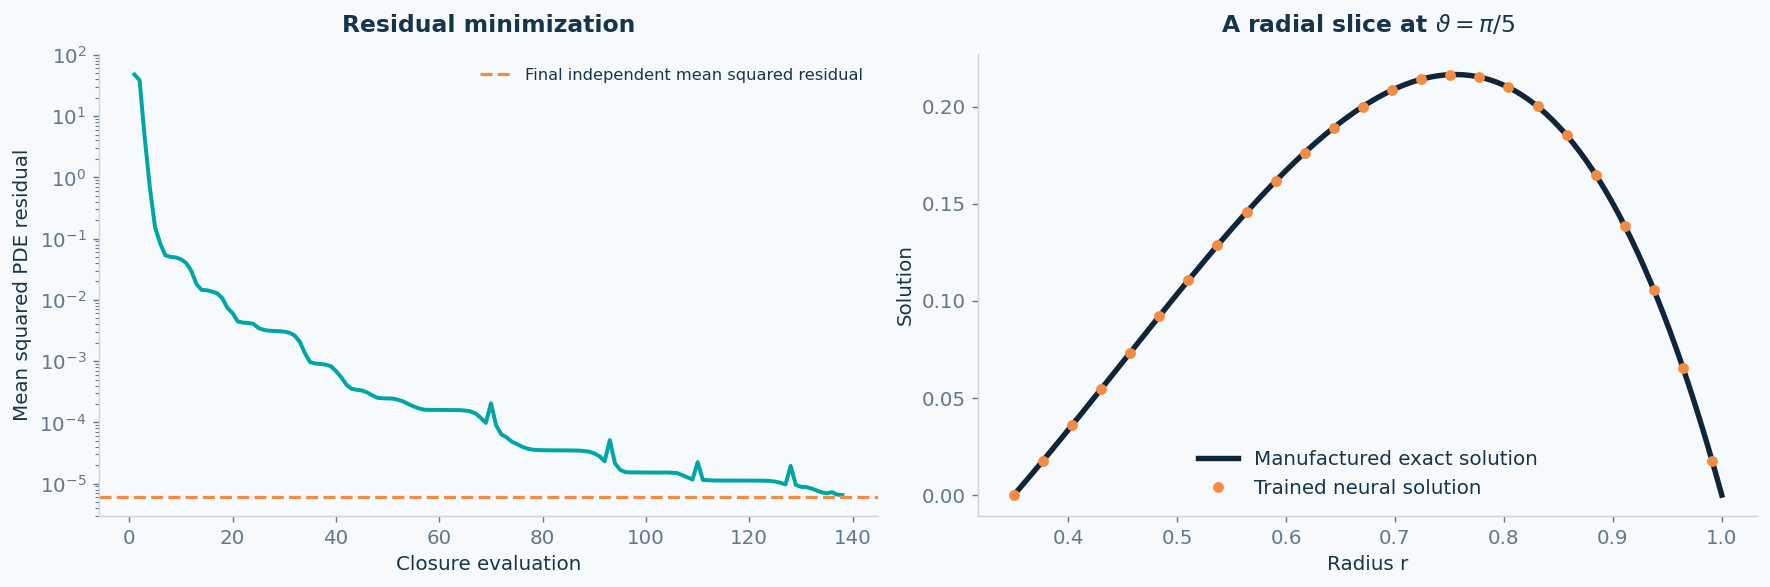

In [9]:
# Convergence and a radial slice give a less impressionistic accuracy check.
geo_slice_r = np.linspace(geo_a, geo_b, 220)
geo_slice_t = np.pi / 5
geo_slice_xy = torch.tensor(np.column_stack((geo_slice_r * np.cos(geo_slice_t),
                                             geo_slice_r * np.sin(geo_slice_t))), dtype=geo_dtype)
with torch.no_grad():
    geo_slice_nn = geo_trial(geo_slice_xy).numpy().ravel()
    geo_slice_ref = geo_exact(geo_slice_xy).numpy().ravel()
geo_diag_fig, geo_diag_ax = plt.subplots(1, 2, figsize=(13.5, 4.4), constrained_layout=True)
geo_diag_ax[0].semilogy(np.arange(1, len(geo_history) + 1), geo_history,
                        color=palette['teal'], lw=2.2)
geo_diag_ax[0].axhline(geo_test_res_rms**2, color=palette['orange'], ls='--',
                       lw=1.8, label='Final independent mean squared residual')
geo_diag_ax[0].set(title='Residual minimization', xlabel='Closure evaluation',
                   ylabel='Mean squared PDE residual')
geo_diag_ax[0].legend(frameon=False, fontsize=9)
geo_diag_ax[1].plot(geo_slice_r, geo_slice_ref, color=palette['navy'], lw=3,
                    label='Manufactured exact solution')
geo_diag_ax[1].plot(geo_slice_r[::9], geo_slice_nn[::9], 'o', color=palette['orange'],
                    ms=5, label='Trained neural solution')
geo_diag_ax[1].set(title=r'A radial slice at $\vartheta=\pi/5$', xlabel='Radius r', ylabel='Solution')
geo_diag_ax[1].legend(frameon=False)
save_figure(geo_diag_fig, 'extra_annulus_diagnostics')

### Try these changes

- **Break the easy high-dimensional structure.** Replace the additive energy integrand by a function concentrated near one corner. Does 8,192-point Monte Carlo still resolve it? Track uncertainty across repeated runs, not just one estimate.
- **Make the hole larger.** Change `geo_a` to 0.7 and rerun the annulus cells. The admissible domain narrows; does the training residual still predict the solution error?
- **Test geometry sampling.** Draw the radius uniformly instead of sampling its square. Compare both models on the same independent area-uniform validation set. Which part of the domain receives disproportionate training attention?
- **Increase solution complexity.** Add angular oscillations to the manufactured solution and derive the new forcing with automatic differentiation. Increase the training point count before attributing a poor result to network capacity.

These examples show how sampling replaces a tensor grid and how a boundary factor handles a curved domain. To assess a full solver, also measure approximation error, training cost, and the work needed to represent the geometry.

## Save this notebook's results

This cell records versions, settings, diagnostics and computed fields, and builds a
local gallery. Report filenames include this notebook's part number, so notebooks
can run independently in any order without overwriting each other's reports.

In [10]:
# Keep reports separate so running one notebook cannot replace another's results.
PART = '04_dimensions_and_geometry'
summary_metrics = list(metrics)
summary_metrics.append(dict(experiment="Annulus PINN", relative_l2=geo_relative_l2,
    residual_rms=geo_test_res_rms, seconds=geo_seconds))

report = dict(part=PART, versions=versions, run_mode=RUN_MODE, seed=SEED, budgets=BUDGET,
    device="cpu", dtype=str(torch.get_default_dtype()), settings=dict(high_dimension_seed=1701, annulus_seed=1702, annulus_lbfgs=130, annulus_points=512, high_dim_repeats=hd_repeats),
    static_figures=FIGURE_NAMES, interactive_figures=INTERACTIVE_NAMES,
    metrics=summary_metrics, elapsed_seconds=time.perf_counter()-NOTEBOOK_START)
(OUTPUT_DIR / f"run_summary_{PART}.json").write_text(json.dumps(report, indent=2))
np.savez_compressed(OUTPUT_DIR / f"computed_fields_{PART}.npz", annulus_x=geo_plot_x, annulus_y=geo_plot_y,
        annulus_prediction=geo_plot_u, annulus_exact=geo_plot_exact)

from html import escape
cards = []
for name in FIGURE_NAMES:
    title = escape(name.replace("_", " ").title())
    cards.append(f'<figure><a href="{name}.png"><img src="{name}.png" alt="{title}"></a>'
                 f'<figcaption>{title} · <a href="{name}.pdf">PDF</a></figcaption></figure>')
links = "".join(f'<li><a href="{name}.html">{escape(name.replace("_", " ").title())}</a></li>'
                for name in INTERACTIVE_NAMES)
page = ('<!doctype html><html lang="en"><meta charset="utf-8">'
        '<meta name="viewport" content="width=device-width, initial-scale=1">'
        '<title>Neural PDE Laboratory</title><style>'
        'body{font-family:system-ui;color:#273442;max-width:1100px;margin:auto;padding:32px}'
        'img{max-width:100%}figure{margin:32px 0}a{color:#4d708a}</style>'
        f'<h1>Neural PDE Laboratory · {escape(PART)}</h1><ul>' + links + '</ul>' + "".join(cards) + '</html>')
(OUTPUT_DIR / f"index_{PART}.html").write_text(page)
print(f"Completed in {report['elapsed_seconds']:.1f} seconds.")
print(f"Saved {len(FIGURE_NAMES)} figure sets and {len(INTERACTIVE_NAMES)} interactive explorers.")
print(f"Reports: run_summary_{PART}.json, computed_fields_{PART}.npz, index_{PART}.html")
for row in summary_metrics:
    print(f"{row['experiment']:32s} relative L2 = {row['relative_l2']:.3e}")

Completed in 7.4 seconds.
Saved 3 figure sets and 1 interactive explorers.
Reports: run_summary_04_dimensions_and_geometry.json, computed_fields_04_dimensions_and_geometry.npz, index_04_dimensions_and_geometry.html
Annulus PINN                     relative L2 = 2.951e-04


[Previous notebook](Neural_PDE_03_inverse.ipynb) · [Laboratory index](Neural_PDE_Laboratory.ipynb) · [Next notebook](Neural_PDE_05_reaction_diffusion.ipynb)